# NB04 — SOTA Baselines, Smoothing & Base Controller (Apple Full-Body)

**Focus:** `UnitreeG1PlaceAppleInBowlFullBody-v1` (`pd_joint_delta_pos`, 37 DOF, fixed root)

This notebook upgrades NB04 by replacing "random reach noise" with a **real Base Controller** that is:
- **Joint-level** (no Cartesian action space, no IK cheating)
- **Ground-truth aligned** with `apple_fullbody_env.py` extras (`tcp_to_apple`, `apple_to_bowl`, `is_grasped`)
- **Robust** (auto-discovers joint indices by name patterns; no magic numbers)
- **SOTA-grade** (online pseudo-Jacobian via RLS + smoothing + jerk limiting)

Includes: leaderboard, plots, GIFs, and error analysis.

> Last updated: 2026-03-03 05:34


## Objectives

1. Build baselines: stand, random, smoothed random, naïve arm extend, directional controller, online RLS pseudo-Jacobian.
2. Produce leaderboard: success-rate, mean return, fail_nan/timeout rates, smoothness metrics.
3. Generate visualizations (plots + GIFs).
4. Error analysis: bucket failures (no reach / no grasp / no place / fail_nan / timeout) and export artifacts.
5. Provide a reusable `BaseController` API for NB07 residual RL.


## Imports & Setup

In [1]:
import os, sys, time, json, math, random
from pathlib import Path

# Set Vulkan vars BEFORE importing sapien/mani_skill
os.environ.setdefault("VK_ICD_FILENAMES", "/usr/share/vulkan/icd.d/lvp_icd.json")
os.environ.setdefault("MESA_VK_DEVICE_SELECT", "10005:0")

import numpy as np
import pandas as pd
import gymnasium as gym

try:
    import torch
except Exception:
    torch = None

import matplotlib.pyplot as plt

try:
    import imageio.v2 as imageio
except Exception:
    imageio = None

# Robust project-root detection (works in VS Code, RunPod, Colab)
try:
    REPO_DIR = Path(__file__).resolve().parent.parent
except NameError:
    _cwd = Path(".").resolve()
    REPO_DIR = _cwd
    for _c in [_cwd, _cwd.parent, _cwd.parent.parent]:
        if (_c / "src").is_dir():
            REPO_DIR = _c
            break

ARTIFACTS_DIR = REPO_DIR / "artifacts" / "NB04_SOTA"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
if torch is not None:
    torch.manual_seed(SEED)

print("REPO_DIR:", REPO_DIR)
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)


REPO_DIR: /root/robotic-sim-dishwash
ARTIFACTS_DIR: /root/robotic-sim-dishwash/artifacts/NB04_SOTA


## Register the custom env

Importing `apple_fullbody_env.py` registers the env via decorators, so Gym can `make()` it.


In [2]:
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

import mani_skill.envs  # noqa: F401 — required before custom env registration

_env_registered = False
try:
    import src.envs as _src_envs  # registers all custom envs via decorators
    _env_registered = True
except Exception:
    pass

if not _env_registered:
    # Fallback: dynamic import directly from file
    import importlib.util as _ilu
    _p = REPO_DIR / "src" / "envs" / "apple_fullbody_env.py"
    if not _p.exists():
        _p = REPO_DIR / "apple_fullbody_env.py"
    assert _p.exists(), f"❌ apple_fullbody_env.py not found under {REPO_DIR}"
    _spec = _ilu.spec_from_file_location("apple_fullbody_env", str(_p))
    _mod = _ilu.module_from_spec(_spec)
    _spec.loader.exec_module(_mod)
    _env_registered = True

print("✅ Custom env registered")
print("   REPO_DIR:", REPO_DIR)
print("   sys.path[0]:", sys.path[0])


/root/robotic-sim-dishwash/.env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/root/robotic-sim-dishwash/.env/lib/python3.12/site-packages/sapien/__init__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


✅ Custom env registered
   REPO_DIR: /root/robotic-sim-dishwash
   sys.path[0]: /root/robotic-sim-dishwash


## Configuration

In [3]:

CFG = {
    "env_id": "UnitreeG1PlaceAppleInBowlFullBody-v1",
    "obs_mode": "state",
    "control_mode": "pd_joint_delta_pos",
    "reward_mode": "normalized_dense",
    "render_mode": "rgb_array",

    "n_eval_episodes": 10,
    "max_steps_per_ep": 300,

    # Action constraints (matches controller bounds in env)
    "action_clip_low": -0.2,
    "action_clip_high":  0.2,
    "jerk_clip": 0.08,

    # Smoothing
    "ema_alpha": 0.20,

    # Control gains
    "k_reach": 1.2,
    "k_place": 1.0,
    "max_arm_delta": 0.08,
    "max_finger_delta": 0.06,

    # Grasp / release heuristics
    "close_fingers_dist": 0.05,
    "release_dist_to_bowl": 0.06,

    # Online RLS pseudo-Jacobian
    "rls_lambda": 0.995,
    "rls_delta":  10.0,
    "rls_explore_sigma": 0.015,
    "rls_explore_decay": 0.995,
    "rls_min_samples": 25,

    # Video
    "record_gif": True,
    "gif_fps": 20,
    "gif_max_frames": 240,
}
(ARTIFACTS_DIR / "nb04_config.json").write_text(json.dumps(CFG, indent=2))
print("✅ Saved config")


✅ Saved config


## Environment factory

In [4]:
from mani_skill.utils.wrappers.gymnasium import CPUGymWrapper

RENDER_AVAILABLE = True

def make_env(seed=SEED, render_mode=CFG["render_mode"], render_backend="cpu"):
    e = gym.make(
        CFG["env_id"],
        num_envs=1,
        obs_mode=CFG["obs_mode"],
        reward_mode=CFG["reward_mode"],
        control_mode=CFG["control_mode"],
        render_mode=render_mode,
        render_backend=render_backend,
    )
    e = CPUGymWrapper(e)
    obs, info = e.reset(seed=seed)
    return e, obs, info

try:
    env, obs0, info0 = make_env(SEED)
except RuntimeError as _e:
    print(f"⚠️  Vulkan unavailable — falling back to render_backend='none'")
    RENDER_AVAILABLE = False
    env, obs0, info0 = make_env(SEED, render_mode=None, render_backend="none")

print("✅ env made  |  render_available:", RENDER_AVAILABLE)
print("action_dim:", env.action_space.shape)
print("obs shape:", obs0.shape)
print("info keys sample:", list(info0.keys())[:10])


[2026-03-03 06:15:47.720] [SAPIEN] [warning] loading multiple convex collision meshes from STL file is unsupported and can result in invalid collision meshes. Do you mean to load a single convex mesh instead?
[2026-03-03 06:15:47.771] [SAPIEN] [warning] loading multiple convex collision meshes from STL file is unsupported and can result in invalid collision meshes. Do you mean to load a single convex mesh instead?
[2026-03-03 06:15:47.784] [SAPIEN] [warning] loading multiple convex collision meshes from STL file is unsupported and can result in invalid collision meshes. Do you mean to load a single convex mesh instead?
[2026-03-03 06:15:47.805] [SAPIEN] [warning] loading multiple convex collision meshes from STL file is unsupported and can result in invalid collision meshes. Do you mean to load a single convex mesh instead?
[2026-03-03 06:15:47.840] [SAPIEN] [warning] loading multiple convex collision meshes from STL file is unsupported and can result in invalid collision meshes. Do yo

✅ env made  |  render_available: True
action_dim: (37,)
obs shape: (94,)
info keys sample: ['elapsed_steps', 'success', 'fail', 'dist_apple_bowl', 'apple_height', 'reconfigure']


## Robust access to extra observations

In [5]:

def _to_np(x):
    if x is None:
        return None
    if torch is not None and torch.is_tensor(x):
        x = x.detach().cpu().numpy()
    if isinstance(x, (list, tuple)):
        x = np.array(x)
    if isinstance(x, np.ndarray) and x.ndim == 2 and x.shape[0] == 1:
        x = x[0]
    return x

def get_extra(obs, info):
    # info first
    if isinstance(info, dict) and any(k in info for k in ["tcp_to_apple","apple_to_bowl","is_grasped"]):
        out = {}
        for k in ["tcp_to_apple","apple_to_bowl","is_grasped","success","fail","dist_apple_bowl"]:
            if k in info:
                out[k] = _to_np(info.get(k))
        return out

    # obs dict variants
    if isinstance(obs, dict):
        if "extra" in obs and isinstance(obs["extra"], dict):
            ex = obs["extra"]
            return {k: _to_np(ex.get(k)) for k in ["tcp_to_apple","apple_to_bowl","is_grasped","tcp_pose"] if k in ex}
        keys = set(obs.keys())
        wanted = ["tcp_to_apple","apple_to_bowl","is_grasped"]
        if any(k in keys for k in wanted):
            return {k: _to_np(obs.get(k)) for k in wanted if k in obs}
    return {}

ex0 = get_extra(obs0, info0)
print("extra keys found:", ex0.keys())


extra keys found: dict_keys([])


## Joint index discovery (no hard-coded indices)

In [6]:

def list_joints(env):
    robot = env.unwrapped.agent.robot
    joints = None
    if hasattr(robot, "active_joints"):
        joints = robot.active_joints
    elif hasattr(robot, "get_active_joints"):
        joints = robot.get_active_joints()
    elif hasattr(robot, "get_joints"):
        joints = robot.get_joints()
    elif hasattr(robot, "joints"):
        joints = robot.joints
    if joints is None:
        raise RuntimeError("Could not locate robot joints via known APIs.")
    names = []
    for j in joints:
        nm = getattr(j, "name", None)
        if nm is None and hasattr(j, "get_name"):
            nm = j.get_name()
        names.append(str(nm))
    return names

joint_names = list_joints(env)
df_joints = pd.DataFrame({"idx": np.arange(len(joint_names)), "name": joint_names})
display(df_joints.head(30))
display(df_joints.tail(30))
df_joints.to_csv(ARTIFACTS_DIR / "joint_names.csv", index=False)
print("✅ Saved joint_names.csv")


,idx,name
0,0,left_hip_pitch_joint
1,1,right_hip_pitch_joint
2,2,torso_joint
3,3,left_hip_roll_joint
4,4,right_hip_roll_joint
5,5,left_shoulder_pitch_joint
6,6,right_shoulder_pitch_joint
7,7,left_hip_yaw_joint
8,8,right_hip_yaw_joint
9,9,left_shoulder_roll_joint


,idx,name
7,7,left_hip_yaw_joint
8,8,right_hip_yaw_joint
9,9,left_shoulder_roll_joint
10,10,right_shoulder_roll_joint
11,11,left_knee_joint
12,12,right_knee_joint
13,13,left_shoulder_yaw_joint
14,14,right_shoulder_yaw_joint
15,15,left_ankle_pitch_joint
16,16,right_ankle_pitch_joint


✅ Saved joint_names.csv


In [7]:

def infer_joint_groups(df_joints: pd.DataFrame):
    names = df_joints["name"].astype(str)

    def has_any(s, keys):
        s = s.lower()
        return any(k in s for k in keys)

    right = names.str.lower().str.contains("right") | names.str.lower().str.contains("r_")
    leg_keys   = ["hip", "knee", "ankle", "toe", "leg"]
    arm_keys   = ["shoulder", "elbow", "wrist", "arm"]
    hand_keys  = ["finger", "hand", "thumb", "index", "middle", "ring", "pinky", "palm"]

    is_leg  = names.apply(lambda x: has_any(x, leg_keys))
    is_arm  = names.apply(lambda x: has_any(x, arm_keys))
    is_hand = names.apply(lambda x: has_any(x, hand_keys))

    arm_right_idx  = df_joints[right & is_arm & (~is_leg)]["idx"].tolist()
    hand_right_idx = df_joints[right & is_hand & (~is_leg)]["idx"].tolist()

    used = set(arm_right_idx + hand_right_idx)
    non_arm_idx = [i for i in df_joints["idx"].tolist() if i not in used]

    return {"arm_right_idx": arm_right_idx, "hand_right_idx": hand_right_idx, "non_arm_idx": non_arm_idx}

JOINT_GROUPS = infer_joint_groups(df_joints)
print("arm_right_idx:", JOINT_GROUPS["arm_right_idx"])
print("hand_right_idx:", JOINT_GROUPS["hand_right_idx"][:20], "... total", len(JOINT_GROUPS["hand_right_idx"]))
print("non_arm_idx frozen:", len(JOINT_GROUPS["non_arm_idx"]))
(ARTIFACTS_DIR / "joint_groups.json").write_text(json.dumps(JOINT_GROUPS, indent=2))
print("✅ Saved joint_groups.json")


arm_right_idx: [5, 6, 9, 10, 13, 14, 18, 22]
hand_right_idx: [] ... total 0
non_arm_idx frozen: 29
✅ Saved joint_groups.json


## Safety utilities: clip + jerk limit + EMA

In [8]:

def clip_action(a: np.ndarray):
    return np.clip(a, CFG["action_clip_low"], CFG["action_clip_high"]).astype(np.float32)

def jerk_limit(a: np.ndarray, prev: np.ndarray):
    if prev is None:
        return a.astype(np.float32)
    d = np.clip(a - prev, -CFG["jerk_clip"], CFG["jerk_clip"])
    return (prev + d).astype(np.float32)

class EMAFilter:
    def __init__(self, alpha=0.2):
        self.alpha = float(alpha)
        self.y = None
    def reset(self):
        self.y = None
    def __call__(self, x: np.ndarray):
        x = x.astype(np.float32)
        if self.y is None:
            self.y = x.copy()
        else:
            self.y = (1.0 - self.alpha) * self.y + self.alpha * x
        return self.y.astype(np.float32)


## Policy API

In [9]:

class PolicyBase:
    name = "policy"
    def reset(self, env, obs, info):
        pass
    def __call__(self, obs, info):
        raise NotImplementedError


## Baseline policies

In [10]:

class StandOnlyPolicy(PolicyBase):
    name = "stand_only"
    def __init__(self, action_dim):
        self.action_dim = action_dim
    def __call__(self, obs, info):
        return np.zeros((self.action_dim,), dtype=np.float32)

class RandomPolicy(PolicyBase):
    name = "random"
    def __init__(self, action_dim, scale=1.0):
        self.action_dim = action_dim
        self.scale = float(scale)
    def __call__(self, obs, info):
        a = np.random.uniform(CFG["action_clip_low"], CFG["action_clip_high"], self.action_dim).astype(np.float32)
        return clip_action(self.scale * a)

class SmoothedRandomPolicy(PolicyBase):
    name = "random_smooth"
    def __init__(self, action_dim, alpha=0.2):
        self.action_dim = action_dim
        self.ema = EMAFilter(alpha)
        self.prev = None
    def reset(self, env, obs, info):
        self.ema.reset()
        self.prev = np.zeros((self.action_dim,), dtype=np.float32)
    def __call__(self, obs, info):
        a = np.random.uniform(CFG["action_clip_low"], CFG["action_clip_high"], self.action_dim).astype(np.float32)
        a = self.ema(a)
        a = jerk_limit(a, self.prev)
        a = clip_action(a)
        self.prev = a
        return a

def _pick_first_joint_by_keywords(df_joints, must_have, must_not=None):
    must_not = must_not or []
    for _, row in df_joints.iterrows():
        nm = str(row["name"]).lower()
        if all(k in nm for k in must_have) and all(k not in nm for k in must_not):
            return int(row["idx"])
    return None

class NaiveArmExtendPolicy(PolicyBase):
    name = "naive_arm_extend"
    def __init__(self, action_dim, df_joints):
        self.action_dim = action_dim
        idx = _pick_first_joint_by_keywords(df_joints, must_have=["right","shoulder"], must_not=["left"])
        self.shoulder_idx = idx if idx is not None else int(action_dim * 0.40)
        self.prev = None
        self.ema = EMAFilter(CFG["ema_alpha"])
    def reset(self, env, obs, info):
        self.prev = np.zeros((self.action_dim,), dtype=np.float32)
        self.ema.reset()
    def __call__(self, obs, info):
        a = np.zeros((self.action_dim,), dtype=np.float32)
        a[self.shoulder_idx] = 0.05
        a = self.ema(a)
        a = jerk_limit(a, self.prev)
        a = clip_action(a)
        self.prev = a
        return a

print("✅ Baselines ready")


✅ Baselines ready


## Helper: phase targets (reach → place)

In [11]:

def _phase_targets(extra):
    tcp_to_apple = extra.get("tcp_to_apple", None)
    apple_to_bowl = extra.get("apple_to_bowl", None)
    is_grasped = extra.get("is_grasped", None)

    if tcp_to_apple is None or apple_to_bowl is None or is_grasped is None:
        return "reach", None, False, False

    tcp_to_apple = np.array(tcp_to_apple, dtype=np.float32).reshape(-1)
    apple_to_bowl = np.array(apple_to_bowl, dtype=np.float32).reshape(-1)
    is_grasped = float(np.array(is_grasped).reshape(-1)[0])

    dist_tcp_apple = float(np.linalg.norm(tcp_to_apple))
    dist_apple_bowl = float(np.linalg.norm(apple_to_bowl))

    if is_grasped < 0.5:
        phase = "reach"
        target = tcp_to_apple
        grasp_cmd = dist_tcp_apple < CFG["close_fingers_dist"]
        release_cmd = False
    else:
        phase = "place"
        target = apple_to_bowl + np.array([0.0, 0.0, 0.15], dtype=np.float32)  # match env goal height bias
        grasp_cmd = True
        release_cmd = dist_apple_bowl < CFG["release_dist_to_bowl"]

    return phase, target, grasp_cmd, release_cmd


## Strong heuristic 1: Directional name-mapped policy

In [12]:

class DirectionalNameMappedPolicy(PolicyBase):
    name = "directional_name_mapped"
    def __init__(self, action_dim, df_joints, joint_groups):
        self.action_dim = action_dim
        self.df = df_joints
        self.groups = joint_groups
        self.prev = None
        self.ema = EMAFilter(CFG["ema_alpha"])

        self.idx_sh_pitch = _pick_first_joint_by_keywords(self.df, ["right","shoulder","pitch"])
        self.idx_sh_roll  = _pick_first_joint_by_keywords(self.df, ["right","shoulder","roll"])
        self.idx_elbow    = _pick_first_joint_by_keywords(self.df, ["right","elbow"])
        self.idx_wrist    = _pick_first_joint_by_keywords(self.df, ["right","wrist"])

        arm = self.groups["arm_right_idx"]
        if self.idx_sh_pitch is None and len(arm) > 0: self.idx_sh_pitch = arm[0]
        if self.idx_sh_roll  is None and len(arm) > 1: self.idx_sh_roll  = arm[1]
        if self.idx_elbow    is None and len(arm) > 2: self.idx_elbow    = arm[2]
        if self.idx_wrist    is None and len(arm) > 3: self.idx_wrist    = arm[3] if len(arm) > 3 else arm[-1]

        self.fingers = self.groups["hand_right_idx"]

    def reset(self, env, obs, info):
        self.prev = np.zeros((self.action_dim,), dtype=np.float32)
        self.ema.reset()

    def __call__(self, obs, info):
        extra = get_extra(obs, info)
        phase, target, grasp_cmd, release_cmd = _phase_targets(extra)

        a = np.zeros((self.action_dim,), dtype=np.float32)

        if target is not None:
            dx, dy, dz = float(target[0]), float(target[1]), float(target[2])
            k = CFG["k_reach"] if phase == "reach" else CFG["k_place"]

            a[self.idx_sh_pitch] = np.clip(+k * dx, -CFG["max_arm_delta"], CFG["max_arm_delta"])
            a[self.idx_sh_roll]  = np.clip(+k * dy, -CFG["max_arm_delta"], CFG["max_arm_delta"])
            a[self.idx_elbow]     = np.clip(-k * dz, -CFG["max_arm_delta"], CFG["max_arm_delta"])
            a[self.idx_wrist]     = np.clip(+0.5 * k * dy, -CFG["max_arm_delta"], CFG["max_arm_delta"])

        if len(self.fingers) > 0:
            if grasp_cmd:
                a[self.fingers] = +CFG["max_finger_delta"]
            if release_cmd:
                a[self.fingers] = -CFG["max_finger_delta"]

        a = self.ema(a)
        a = jerk_limit(a, self.prev)
        a = clip_action(a)
        self.prev = a
        return a

print("✅ Directional policy ready")


✅ Directional policy ready


## Strong heuristic 2 (SOTA): Online RLS pseudo-Jacobian policy

In [13]:

class OnlineRLSPseudoJacobianPolicy(PolicyBase):
    name = "rls_pseudo_jacobian"
    def __init__(self, action_dim, df_joints, joint_groups):
        self.action_dim = action_dim
        self.df = df_joints
        self.groups = joint_groups

        self.arm = np.array(self.groups["arm_right_idx"], dtype=int)
        self.fingers = np.array(self.groups["hand_right_idx"], dtype=int)

        self.prev = None
        self.ema = EMAFilter(CFG["ema_alpha"])

        self.J = None
        self.P = None
        self.samples = 0
        self.explore_sigma = CFG["rls_explore_sigma"]

        self.prev_tcp = None
        self.prev_t2a = None
        self.prev_arm_action = None

        self.prior = DirectionalNameMappedPolicy(action_dim, df_joints, joint_groups)

    def reset(self, env, obs, info):
        self.prev = np.zeros((self.action_dim,), dtype=np.float32)
        self.ema.reset()
        self.samples = 0
        self.explore_sigma = CFG["rls_explore_sigma"]

        m = max(1, len(self.arm))
        self.J = np.zeros((3, m), dtype=np.float32)
        self.P = (CFG["rls_delta"] * np.eye(m)).astype(np.float32)

        self.prev_tcp = None
        self.prev_t2a = None
        self.prev_arm_action = None

        self.prior.reset(env, obs, info)

        if len(self.arm) == 0:
            print("⚠️ arm_right_idx empty → fallback to prior policy")

    def _tcp_delta(self, obs, info):
        # Prefer tcp_pose if available
        ex = get_extra(obs, info)
        if isinstance(ex, dict) and ("tcp_pose" in ex):
            tcp_pose = np.array(ex["tcp_pose"], dtype=np.float32).reshape(-1)
            tcp_pos = tcp_pose[:3]
            if self.prev_tcp is None:
                self.prev_tcp = tcp_pos.copy()
                return None
            d = tcp_pos - self.prev_tcp
            self.prev_tcp = tcp_pos.copy()
            return d.astype(np.float32)

        # Fallback approximation: delta(tcp) ≈ -delta(tcp_to_apple)
        t2a = ex.get("tcp_to_apple", None)
        if t2a is None:
            return None
        t2a = np.array(t2a, dtype=np.float32).reshape(-1)
        if self.prev_t2a is None:
            self.prev_t2a = t2a.copy()
            return None
        d = -(t2a - self.prev_t2a)
        self.prev_t2a = t2a.copy()
        return d.astype(np.float32)

    def _rls_update(self, a_arm, y):
        m = a_arm.shape[0]
        a = a_arm.reshape(m, 1).astype(np.float32)

        Pa = self.P @ a
        denom = float(CFG["rls_lambda"] + (a.T @ Pa)[0,0])
        k = (Pa / denom).astype(np.float32)  # m x 1

        y = y.reshape(3, 1).astype(np.float32)
        pred = (self.J @ a).astype(np.float32)
        e = (y - pred).astype(np.float32)

        self.J = (self.J + (e @ k.T)).astype(np.float32)
        self.P = ((self.P - (k @ a.T @ self.P)) / CFG["rls_lambda"]).astype(np.float32)
        self.samples += 1

    def _choose_arm_action(self, desired_tcp_delta):
        m = self.J.shape[1]
        reg = 1e-3
        J = self.J
        A = (J.T @ J + reg * np.eye(m)).astype(np.float32)
        b = (J.T @ desired_tcp_delta.reshape(3,1)).astype(np.float32)
        try:
            a = np.linalg.solve(A, b).reshape(-1)
        except Exception:
            a = (np.linalg.pinv(J) @ desired_tcp_delta.reshape(3,1)).reshape(-1)
        a = np.clip(a, -CFG["max_arm_delta"], CFG["max_arm_delta"]).astype(np.float32)
        return a

    def __call__(self, obs, info):
        if len(self.arm) == 0:
            return self.prior(obs, info)

        # Update RLS using last arm action and observed tcp delta
        d_tcp = self._tcp_delta(obs, info)
        if (d_tcp is not None) and (self.prev_arm_action is not None):
            self._rls_update(self.prev_arm_action, d_tcp)

        extra = get_extra(obs, info)
        phase, target, grasp_cmd, release_cmd = _phase_targets(extra)
        if target is None:
            return self.prior(obs, info)

        k = CFG["k_reach"] if phase == "reach" else CFG["k_place"]
        desired = (k * np.array(target, dtype=np.float32)).astype(np.float32)

        # limit desired magnitude
        mag = float(np.linalg.norm(desired) + 1e-8)
        if mag > 0.08:
            desired = desired * (0.08 / mag)

        use_rls = self.samples >= CFG["rls_min_samples"]

        if not use_rls:
            a = self.prior(obs, info).copy()
            noise = np.random.randn(len(self.arm)).astype(np.float32) * self.explore_sigma
            a[self.arm] = np.clip(a[self.arm] + noise, -CFG["max_arm_delta"], CFG["max_arm_delta"]).astype(np.float32)
        else:
            a = np.zeros((self.action_dim,), dtype=np.float32)
            a_arm = self._choose_arm_action(desired)
            noise = np.random.randn(len(self.arm)).astype(np.float32) * self.explore_sigma
            a_arm = np.clip(a_arm + noise, -CFG["max_arm_delta"], CFG["max_arm_delta"]).astype(np.float32)
            a[self.arm] = a_arm

        if self.fingers.size > 0:
            if grasp_cmd:
                a[self.fingers] = +CFG["max_finger_delta"]
            if release_cmd:
                a[self.fingers] = -CFG["max_finger_delta"]

        a = self.ema(a)
        a = jerk_limit(a, self.prev)
        a = clip_action(a)

        self.prev = a
        self.prev_arm_action = a[self.arm].copy()
        self.explore_sigma *= CFG["rls_explore_decay"]
        return a

print("✅ RLS policy ready")


✅ RLS policy ready


## Evaluation harness (metrics + optional GIF)

In [22]:

def rollout(env, policy, seed=SEED, max_steps=None, record=False, tag="policy"):
    max_steps = max_steps or CFG["max_steps_per_ep"]
    obs, info = env.reset(seed=seed)

    if hasattr(policy, "reset"):
        policy.reset(env, obs, info)

    frames = []
    if record and CFG["record_gif"] and (imageio is not None):
        fr = env.render()
        if fr is not None:
            frames.append(fr)

    prev_action = np.zeros(env.action_space.shape, dtype=np.float32)

    ep_rew = 0.0
    action_norms, jerk_norms = [], []
    dist_tcp_apple, dist_apple_bowl = [], []
    ever_grasped = False

    terminated = False
    truncated = False
    final_info = {}
    t = 0

    for t in range(max_steps):
        a = policy(obs, info)
        obs, rew, terminated, truncated, info = env.step(a)
        ep_rew += float(rew)

        # Always keep last info so final_info is populated even on timeout
        final_info = dict(info)

        action_norms.append(float(np.linalg.norm(a)))
        jerk_norms.append(float(np.linalg.norm(a - prev_action)))
        prev_action = a

        ex = get_extra(obs, info)
        if "tcp_to_apple" in ex:
            dist_tcp_apple.append(float(np.linalg.norm(np.atleast_1d(np.asarray(ex["tcp_to_apple"], dtype=float)).ravel())))
        if "dist_apple_bowl" in info:
            dist_apple_bowl.append(float(np.atleast_1d(np.asarray(_to_np(info["dist_apple_bowl"]), dtype=float)).ravel()[0]))
        if "is_grasped" in ex:
            ever_grasped = ever_grasped or (float(np.atleast_1d(np.asarray(ex["is_grasped"], dtype=float)).ravel()[0]) > 0.5)

        if record and CFG["record_gif"] and (imageio is not None) and len(frames) < CFG["gif_max_frames"]:
            fr = env.render()
            if fr is not None:
                frames.append(fr)

        if bool(terminated) or bool(truncated):
            break

    # If loop exhausted without env signalling done → treat as timeout
    if not bool(terminated) and not bool(truncated):
        truncated = True

    success = bool(final_info.get("success", False))
    # success may be a numpy scalar / tensor — normalise
    try:
        success = bool(np.atleast_1d(np.asarray(success)).ravel()[0])
    except Exception:
        pass

    fail_nan = bool(final_info.get("fail", False))
    try:
        fail_nan = bool(np.atleast_1d(np.asarray(fail_nan)).ravel()[0])
    except Exception:
        pass

    timeout = bool(truncated) and (not bool(terminated))

    out = {
        "tag": tag,
        "seed": seed,
        "return": ep_rew,
        "steps": t + 1,
        "success": success,
        "fail_nan": fail_nan,
        "timeout": timeout,
        "terminated": bool(terminated),
        "truncated": bool(truncated),
        "mean_action_norm": float(np.mean(action_norms)) if action_norms else 0.0,
        "mean_jerk_norm": float(np.mean(jerk_norms)) if jerk_norms else 0.0,
        "max_action_norm": float(np.max(action_norms)) if action_norms else 0.0,
        "max_jerk_norm": float(np.max(jerk_norms)) if jerk_norms else 0.0,
        "min_dist_tcp_apple": float(np.min(dist_tcp_apple)) if dist_tcp_apple else np.nan,
        "min_dist_apple_bowl": float(np.min(dist_apple_bowl)) if dist_apple_bowl else np.nan,
        "ever_grasped": bool(ever_grasped),
    }
    return out, frames

def eval_policy(env, policy, name, n_episodes=None, seed0=SEED, record_gif=False):
    n_episodes = n_episodes or CFG["n_eval_episodes"]
    rows = []
    gif_path = None
    rep_frames = None

    for i in range(n_episodes):
        do_record = record_gif and (i == 0)
        row, frames = rollout(env, policy, seed=seed0 + i, record=do_record, tag=name)
        rows.append(row)
        if do_record:
            rep_frames = frames

    df = pd.DataFrame(rows)
    if record_gif and rep_frames is not None and imageio is not None and len(rep_frames) > 0:
        gif_path = ARTIFACTS_DIR / f"{name}.gif"
        imageio.mimsave(gif_path, rep_frames, fps=CFG["gif_fps"])
        print("🎞️ Saved", gif_path)
    return df, gif_path

print("✅ eval harness ready")


✅ eval harness ready


## Run baseline suite + Leaderboard

In [23]:

action_dim = env.action_space.shape[0]
policies = [
    StandOnlyPolicy(action_dim),
    RandomPolicy(action_dim),
    SmoothedRandomPolicy(action_dim, alpha=CFG["ema_alpha"]),
    NaiveArmExtendPolicy(action_dim, df_joints),
    DirectionalNameMappedPolicy(action_dim, df_joints, JOINT_GROUPS),
    OnlineRLSPseudoJacobianPolicy(action_dim, df_joints, JOINT_GROUPS),
]

all_results = []
gif_paths = {}

for pol in policies:
    print("\n" + "="*80)
    print("Evaluating:", pol.name)
    df_res, gif_path = eval_policy(env, pol, pol.name, record_gif=True)
    df_res["policy"] = pol.name
    all_results.append(df_res)
    if gif_path is not None:
        gif_paths[pol.name] = str(gif_path)

df_all = pd.concat(all_results, ignore_index=True)
df_all.to_csv(ARTIFACTS_DIR / "nb04_all_results.csv", index=False)
(ARTIFACTS_DIR / "nb04_gifs.json").write_text(json.dumps(gif_paths, indent=2))
print("✅ Saved nb04_all_results.csv and nb04_gifs.json")

lb = (df_all.groupby("policy")
      .agg(
          episodes=("return","count"),
          success_rate=("success","mean"),
          fail_nan_rate=("fail_nan","mean"),
          timeout_rate=("timeout","mean"),
          mean_return=("return","mean"),
          std_return=("return","std"),
          mean_steps=("steps","mean"),
          mean_action_norm=("mean_action_norm","mean"),
          mean_jerk_norm=("mean_jerk_norm","mean"),
          ever_grasped_rate=("ever_grasped","mean"),
          min_dist_tcp_apple=("min_dist_tcp_apple","mean"),
          min_dist_apple_bowl=("min_dist_apple_bowl","mean"),
      )
      .sort_values(["success_rate","mean_return"], ascending=False)
)
display(lb)
lb.to_csv(ARTIFACTS_DIR / "nb04_leaderboard.csv")
print("✅ Saved nb04_leaderboard.csv")



Evaluating: stand_only


🎞️ Saved /root/robotic-sim-dishwash/artifacts/NB04_SOTA/stand_only.gif

Evaluating: random
🎞️ Saved /root/robotic-sim-dishwash/artifacts/NB04_SOTA/random.gif

Evaluating: random_smooth
🎞️ Saved /root/robotic-sim-dishwash/artifacts/NB04_SOTA/random_smooth.gif

Evaluating: naive_arm_extend
🎞️ Saved /root/robotic-sim-dishwash/artifacts/NB04_SOTA/naive_arm_extend.gif

Evaluating: directional_name_mapped
🎞️ Saved /root/robotic-sim-dishwash/artifacts/NB04_SOTA/directional_name_mapped.gif

Evaluating: rls_pseudo_jacobian
🎞️ Saved /root/robotic-sim-dishwash/artifacts/NB04_SOTA/rls_pseudo_jacobian.gif
✅ Saved nb04_all_results.csv and nb04_gifs.json


,episodes,success_rate,fail_nan_rate,timeout_rate,mean_return,std_return,mean_steps,mean_action_norm,mean_jerk_norm,ever_grasped_rate,min_dist_tcp_apple,min_dist_apple_bowl
policy,,,,,,,,,,,,
rls_pseudo_jacobian,10,0.0,0.0,1.0,0.459666,0.066663,300.0,0.000000,0.000000,0.0,NaN,0.400024
directional_name_mapped,10,0.0,0.0,1.0,0.459256,0.066015,300.0,0.000000,0.000000,0.0,NaN,0.400024
stand_only,10,0.0,0.0,1.0,0.458326,0.066308,300.0,0.000000,0.000000,0.0,NaN,0.400024
random_smooth,10,0.0,0.0,1.0,0.320961,0.122441,300.0,0.237715,0.148953,0.0,NaN,0.400024
random,10,0.0,0.0,1.0,0.093951,0.153267,300.0,0.699856,0.987843,0.0,NaN,0.400024
naive_arm_extend,10,0.0,0.0,1.0,0.089618,0.022800,300.0,0.050000,0.000167,0.0,NaN,0.400024


✅ Saved nb04_leaderboard.csv


## Plots

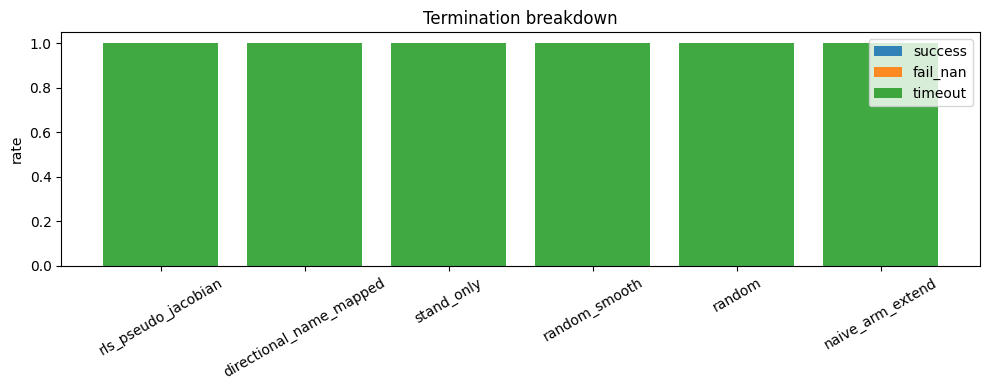

/tmp/ipykernel_10469/2443476708.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showfliers=False)


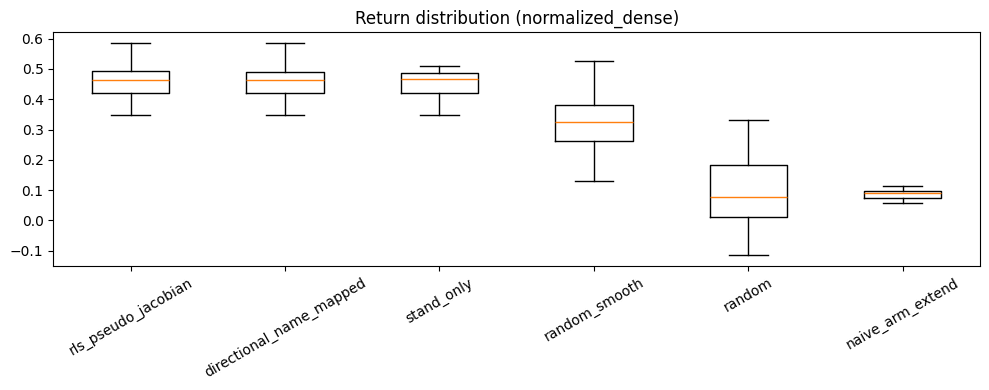

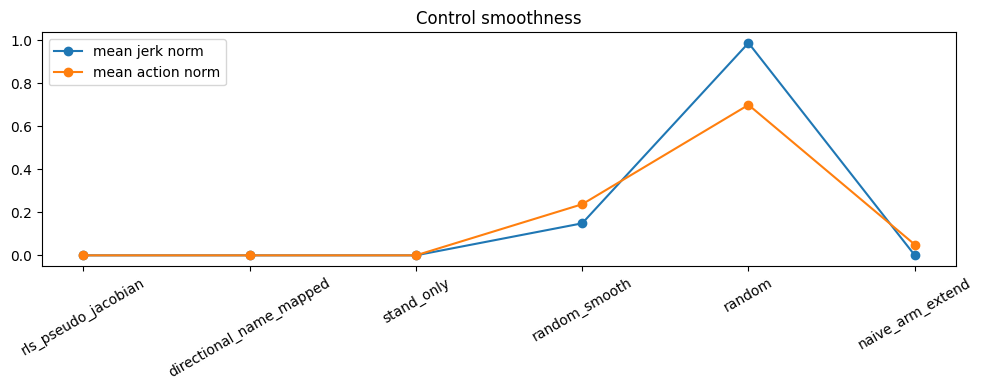

✅ Saved plots to /root/robotic-sim-dishwash/artifacts/NB04_SOTA


In [24]:

fig, ax = plt.subplots(figsize=(10,4))
order = lb.index.tolist()
ax.bar(order, lb["success_rate"].values, label="success", alpha=0.9)
ax.bar(order, lb["fail_nan_rate"].values, bottom=lb["success_rate"].values, label="fail_nan", alpha=0.9)
ax.bar(order, lb["timeout_rate"].values, bottom=(lb["success_rate"]+lb["fail_nan_rate"]).values, label="timeout", alpha=0.9)
ax.set_title("Termination breakdown")
ax.set_ylabel("rate")
ax.set_ylim(0,1.05)
ax.legend()
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / "plot_termination_breakdown.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(10,4))
data = [df_all[df_all.policy==p]["return"].values for p in order]
ax.boxplot(data, labels=order, showfliers=False)
ax.set_title("Return distribution (normalized_dense)")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / "plot_returns_box.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(order, lb["mean_jerk_norm"].values, marker="o", label="mean jerk norm")
ax.plot(order, lb["mean_action_norm"].values, marker="o", label="mean action norm")
ax.set_title("Control smoothness")
ax.legend()
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / "plot_smoothness.png", dpi=160)
plt.show()

print("✅ Saved plots to", ARTIFACTS_DIR)


## Show best-policy GIF (if available)

Best policy: rls_pseudo_jacobian
GIF: /root/robotic-sim-dishwash/artifacts/NB04_SOTA/rls_pseudo_jacobian.gif


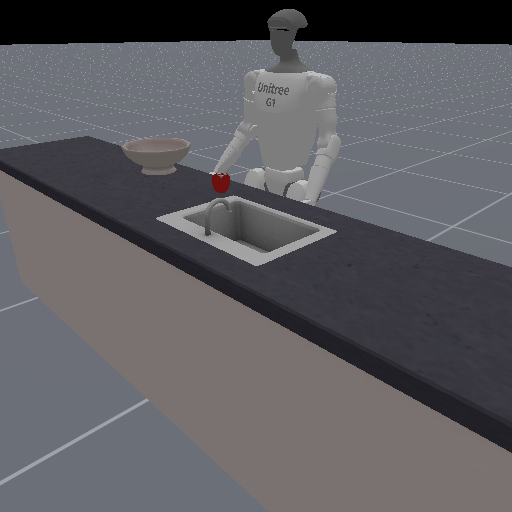

In [25]:

best_policy = lb.index[0]
print("Best policy:", best_policy)
gif = gif_paths.get(best_policy, None)
print("GIF:", gif)

try:
    from IPython.display import Image, display
    if gif is not None:
        display(Image(filename=gif))
except Exception as e:
    print("Inline display not available:", e)


## Error analysis

In [26]:

def categorize(row):
    if row["fail_nan"]:
        return "fail_nan"
    if row["success"]:
        return "success"
    if row["timeout"]:
        return "timeout"

    dA = row["min_dist_tcp_apple"]
    dB = row["min_dist_apple_bowl"]
    grasp = row["ever_grasped"]

    if np.isnan(dA) or dA > 0.12:
        return "no_reach"
    if not grasp:
        return "reach_no_grasp"
    if np.isnan(dB) or dB > 0.15:
        return "grasp_no_place"
    return "other_fail"

df_all["fail_type"] = df_all.apply(categorize, axis=1)
fail_summary = (df_all.groupby(["policy","fail_type"]).size().reset_index(name="count"))
display(fail_summary)
fail_summary.to_csv(ARTIFACTS_DIR / "nb04_fail_summary.csv", index=False)

outliers = df_all.sort_values(["fail_nan","max_jerk_norm","max_action_norm"], ascending=False).head(30)
outliers.to_csv(ARTIFACTS_DIR / "nb04_outlier_episodes_top30.csv", index=False)
print("✅ Saved nb04_fail_summary.csv and nb04_outlier_episodes_top30.csv")


,policy,fail_type,count
0,directional_name_mapped,timeout,10
1,naive_arm_extend,timeout,10
2,random,timeout,10
3,random_smooth,timeout,10
4,rls_pseudo_jacobian,timeout,10
5,stand_only,timeout,10


✅ Saved nb04_fail_summary.csv and nb04_outlier_episodes_top30.csv


## Export BaseController for NB07

In [27]:

class BaseController:
    def __init__(self, controller_policy: PolicyBase):
        self.policy = controller_policy
    def reset(self, env, obs, info):
        if hasattr(self.policy, "reset"):
            self.policy.reset(env, obs, info)
    def act(self, obs, info):
        return self.policy(obs, info)

base_controller = BaseController(OnlineRLSPseudoJacobianPolicy(action_dim, df_joints, JOINT_GROUPS))
print("✅ BaseController ready:", type(base_controller.policy).__name__)


✅ BaseController ready: OnlineRLSPseudoJacobianPolicy
